In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Problem Statement:

### A leading retail company wants to better understand its customer's shopping behavior in order to improve sales, customer satisfaction and long-term loyalty. The management team has noticed changes in purchasing patterns across demographics, product categories, and sales channels (online vs. offline). They are particularly interested in uncovering which factors, such as discounts, reviews, seasons, or payment preferences, drive consumer decisions and repeat purchases.

### You are tasked with analyzing the company's consumer behavior dataset to answer the following overarching business question:

### "How can the company leverage consumer shopping data to identify trends, improve customer engagement and optimize marketing and product strategies?"

In [2]:
df = pd.read_csv("Customer_Behaviour_dataset.csv")

In [3]:
df.shape

(3900, 18)

In [4]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
df.columns.tolist()

['Customer ID',
 'Age',
 'Gender',
 'Item Purchased',
 'Category',
 'Purchase Amount (USD)',
 'Location',
 'Size',
 'Color',
 'Season',
 'Review Rating',
 'Subscription Status',
 'Shipping Type',
 'Discount Applied',
 'Promo Code Used',
 'Previous Purchases',
 'Payment Method',
 'Frequency of Purchases']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [7]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [10]:
Q1 = df['Review Rating'].quantile(0.25)
Q3 = df['Review Rating'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower}, Upper bound: {upper}")
print(df[(df['Review Rating'] < lower) | (df['Review Rating'] > upper)].shape[0])

Q1: 3.1, Q3: 4.4, IQR: 1.3000000000000003
Lower bound: 1.1499999999999997, Upper bound: 6.3500000000000005
0


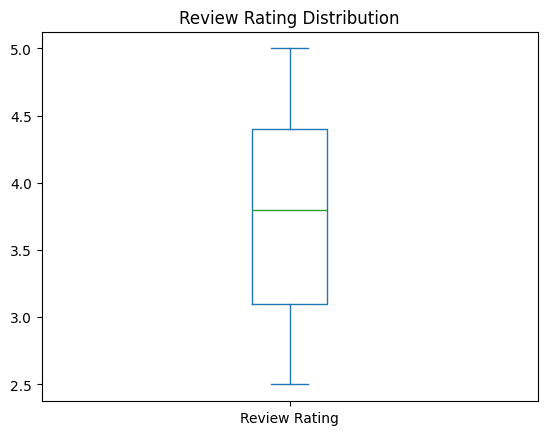

In [11]:
import matplotlib.pyplot as plt
df['Review Rating'].plot(kind='box')
plt.title('Review Rating Distribution')
plt.show()

### Now Implement mean on missing values of "Review Rating"

In [12]:
df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].mean())

In [13]:
df['Review Rating'].isnull().sum()

np.int64(0)

### Here's your complete finalized column mapping:

Age group shops most → Age, Customer ID<br>
Demographic least online → Age, Gender, Shipping Type<br>
Product sells most across demographics → Item Purchased, Age, Gender<br>
Worst rated category → Category, Review Rating<br>
Highest sales season → Season, Purchase Amount (USD), Item Purchased<br>
Discounts and repeat purchases → Discount Applied, Previous Purchases<br>
Reviews and repeat purchases → Review Rating, Frequency of Purchases<br>
Online vs offline product sales → Item Purchased, Shipping Type<br>
Payment method usage → Payment Method<br>
Customers who shop least → Customer ID, Frequency of Purchases<br>

In [14]:
df['Age'].describe()

count    3900.000000
mean       44.068462
std        15.207589
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Age, dtype: float64

In [15]:
bins = [0, 25, 35, 45, 55, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '56-70']

df['Age Group'] = pd.cut(df['Age'], bins = bins, labels = labels)

In [16]:
df['Age Group'].value_counts()

Age Group
56-70    1105
46-55     753
26-35     742
36-45     729
18-25     571
Name: count, dtype: int64

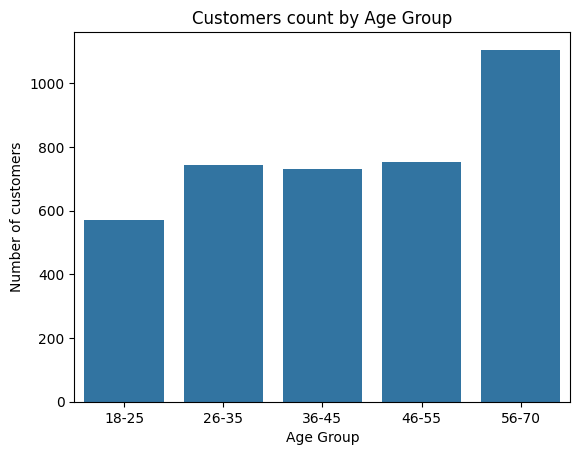

In [17]:
sns.countplot(x = 'Age Group', data = df)

plt.title("Customers count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of customers")
plt.show()

### Question 1. Which age group shops with us the most?
    
### Solution - The company's largest customer base is older adults (56-70). Marketing strategies should prioritize this demographic while exploring ways to attract younger customers (18-25) who are currently underrepresented.

### Move to the Next Question

In [18]:
df['Shipping Type'].value_counts()

Shipping Type
Free Shipping     675
Standard          654
Store Pickup      650
Next Day Air      648
Express           646
2-Day Shipping    627
Name: count, dtype: int64

In [19]:
df['Shopping Channel'] = df['Shipping Type'].apply(lambda x: 'Offline' if x == 'Store Pickup' else 'Online')

In [20]:
df['Shopping Channel'].value_counts()

Shopping Channel
Online     3250
Offline     650
Name: count, dtype: int64

### As we can see here around 83% of purchases are online, only 17% offline.

### Your demographics are "Age Group" and "Gender". You want to find which of these shops offline the most (or online the least).
### Let's tackle Gender first since it's simpler.

In [21]:
df[df['Shopping Channel'] == 'Offline']['Gender'].value_counts()

Gender
Male      456
Female    194
Name: count, dtype: int64

In [22]:
df['Gender'].value_counts()

Gender
Male      2652
Female    1248
Name: count, dtype: int64

### Male offline % = 17%
### Female offline % = 15%

Exactly right! And notice how close those numbers actually are — 17% vs 15%. That's barely a difference.
Gender has minimal impact on offline vs online shopping preference. Both males and females shop online at nearly the same rate (~83-85%). Gender is not a strong differentiator for shopping channel.

That's actually a more valuable insight than a dramatic difference would be — it tells the business don't waste budget segmenting campaigns by gender for online/offline channel strategy.

In [23]:
# Now check Age Group for offline shopping:

offline_by_age = df[df['Shopping Channel'] == 'Offline']['Age Group'].value_counts()
total_by_age = df['Age Group'].value_counts()

offline_pct = (offline_by_age / total_by_age * 100).round(1)

print(pd.DataFrame({'Offline Count': offline_by_age, 'Offline %': offline_pct}))

           Offline Count  Offline %
Age Group                          
18-25                100       17.5
26-35                118       15.9
36-45                133       18.2
46-55                137       18.2
56-70                162       14.7


### Question 2. Which demographic engages least in online shopping?

### Solution 2-  Neither gender nor age group significantly influences whether customers shop online or offline. Online shopping is uniformly preferred across all demographics at roughly 82-85%. This suggests the company's online platform has broad appeal across all customer segments.

### Now we move next question

### Question 3. Which product sells most across demographics? demographics -- AGE Group, Gender

In [24]:
df['Item Purchased'].nunique()

25

In [25]:
df['Item Purchased'].value_counts().head(10)

Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: int64

In [26]:
df[df['Item Purchased'] == 'Blouse']['Gender'].value_counts()

Gender
Male      105
Female     66
Name: count, dtype: int64

<strong>Business insight</strong>: The company doesn't have a "hero product" driving most revenue. This could mean either customers have diverse preferences, or the dataset is synthetic/simulated.<br>
This is actually important context for Q3 — since no product dramatically outsells others, <strong>the more interesting question becomes which product each demographic prefers</strong>, not which one wins overall.

In [27]:
df.groupby('Gender')['Item Purchased'].value_counts().groupby(level=0).head(3)

Gender  Item Purchased
Female  Blouse             66
        Shirt              59
        Sandals            59
Male    Pants             123
        Jewelry           119
        Sweater           114
Name: count, dtype: int64

In [28]:
df.groupby('Age Group')['Item Purchased'].value_counts().groupby(level=0).head(3)

Age Group  Item Purchased
18-25      Sweater           31
           Coat              29
           Dress             29
26-35      Shirt             44
           Backpack          39
           Jewelry           38
36-45      Scarf             45
           Pants             44
           Jacket            39
46-55      Shoes             43
           Boots             37
           Sandals           37
56-70      Jewelry           63
           Handbag           52
           Dress             52
Name: count, dtype: int64

<strong>Product preferences vary significantly across demographics. Age is a stronger predictor of product preference than gender. The company should move away from one-size-fits-all marketing and adopt age-segmented product strategies</strong>

<strong>Key Insights:</strong>

Each age group has a distinctly different product preference<br>
56-70 gravitates toward premium products like Jewelry and Handbags<br>
46-55 exclusively buys footwear across all seasons<br>
18-25 is fashion and trend driven<br>
26-35 balances professional and lifestyle needs<br>

<strong>Recommendations:</strong>

Target 18-25 through social media and influencer marketing with trendy fashion<br>
Target 26-35 with professional and lifestyle products<br>
Market premium comfort footwear specifically to 46-55 segment<br>
Promote luxury jewelry and handbag lines to 56-70 through email and loyalty programs<br>

<strong>Q4 — Which product category receives the worst ratings?</strong> - Category, Review Rating

In [29]:
df['Review Rating'].nunique()

27

In [30]:
df['Review Rating'].value_counts().head(10)

Review Rating
3.4    182
4.0    181
4.6    170
4.2    169
2.9    166
4.9    162
3.9    162
3.0    162
2.6    158
4.4    158
Name: count, dtype: int64

In [31]:
df.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Group,Shopping Channel
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,46-55,Online
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,18-25,Online
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,46-55,Online
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,18-25,Online
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,36-45,Online


In [32]:
df.groupby('Category')['Review Rating'].mean().round(2).sort_values()

Category
Clothing       3.72
Outerwear      3.75
Accessories    3.77
Footwear       3.79
Name: Review Rating, dtype: float64

In [33]:
df['Category'].unique().tolist()

['Clothing', 'Footwear', 'Outerwear', 'Accessories']

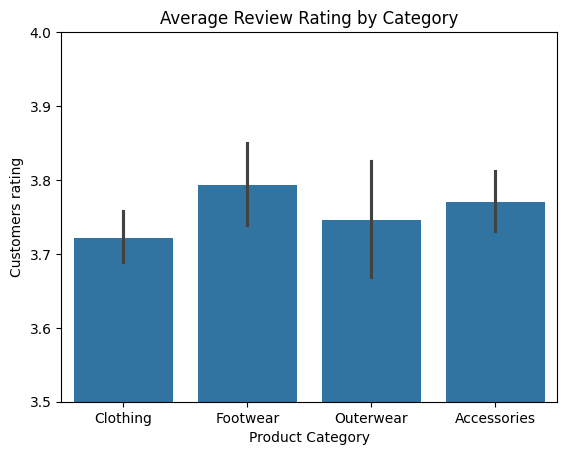

In [34]:
sns.barplot(x='Category', y='Review Rating', data=df)

plt.title("Average Review Rating by Category")
plt.xlabel("Product Category")
plt.ylabel("Customers rating")
plt.ylim(3.5, 4.0)

# plt.savefig("graph.png")
plt.show()

<strong>Q4 — Which product category receives the worst ratings?</strong> - Category, Review Rating

<strong>What:</strong> All product categories are rated between 3.72 and 3.79 — a difference of only 0.07 across all categories.<br>

<strong>So what:</strong> Product category is not a driver of customer satisfaction. No single category stands out as significantly better or worse. Overall satisfaction is moderate — nobody is extremely happy or unhappy with any category.<br>

<strong>Now what:</strong>
- Since all categories score similarly, the business should investigate what drives ratings beyond category — perhaps delivery experience, product quality consistency, or pricing.<br>
- Conduct customer surveys to understand why ratings aren't exceeding 4.0<br>
- Focus on converting moderate satisfaction (3.75) to high satisfaction (4.5+) — this is where loyalty and repeat purchases are won

In [35]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Group,Shopping Channel
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,46-55,Online
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,18-25,Online
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,46-55,Online
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,18-25,Online
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,36-45,Online


<strong>Q5 — Which season sees the highest sales and which product sells most in that season? —</strong> Season, Purchase Amount (USD) and Item Purchased

In [36]:
df['Season'].unique().tolist()

['Winter', 'Spring', 'Summer', 'Fall']

In [37]:
df.groupby('Season')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: Purchase Amount (USD), dtype: int64

In [38]:
df.groupby('Season')['Item Purchased'].value_counts().groupby(level=0).head(3)

Season  Item Purchased
Fall    Jacket            54
        Hat               50
        Handbag           48
Spring  Sweater           52
        Shorts            47
        Coat              46
Summer  Pants             50
        Jewelry           47
        Dress             47
Winter  Sunglasses        52
        Pants             51
        Shirt             50
Name: count, dtype: int64

<strong>On total sales difference ($4,241):</strong>

- this difference is meaningful from a business perspective. Good call not dismissing it like the rating differences earlier. You're learning when a difference matters and when it doesn't.


<strong>Complete Q5 Business Recommendations:</strong>
- Stock Jackets heavily before Fall season<br>
- Run winter gift campaigns featuring Sunglasses in December<br>
- Launch summer fashion campaigns featuring Pants, Jewelry and Dresses<br>
- Focus marketing budget on Fall — highest revenue season<br>

In [39]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Group,Shopping Channel
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,46-55,Online
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,18-25,Online
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,46-55,Online
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,18-25,Online
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,36-45,Online


<strong>Q6 — Do customers who use discounts come back more often? —</strong> Discount Applied and Previous Purchases

In [40]:
df.groupby('Discount Applied')['Previous Purchases'].mean().round(2)

Discount Applied
No     25.06
Yes    25.74
Name: Previous Purchases, dtype: float64

<strong>The correct interpretation:</strong><br>

<strong>What:</strong> Customers who received discounts average 25.74 previous purchases vs 25.06 without discounts — a difference of only 0.68.<br>
<strong>So what:</strong> Discounts are not a strong driver of repeat purchases. Loyal customers and non-loyal customers receive discounts at similar rates.<br>
<strong>Now what:</strong> The business should reconsider its discount strategy — they may be giving discounts to customers who would have purchased anyway, which hurts margins without improving loyalty.<br>


<strong>This is actually a very important business insight:</strong><br>
It suggests discounts are being applied broadly rather than strategically. A smarter approach would be:<br>

- Give discounts to at-risk customers who haven't purchased recently.<br>
- Reward genuinely loyal customers with exclusive discounts.<br>
- Stop giving discounts to customers who buy regardless.<br>

In [41]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Group,Shopping Channel
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,46-55,Online
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,18-25,Online
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,46-55,Online
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,18-25,Online
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,36-45,Online


<strong>Q7 — Do better reviewed products lead to more repeat purchases? —</strong> Review Rating and Frequency of Purchases

In [42]:
frequency_map = {
    'Weekly': 7,
    'Bi-Weekly': 6,
    'Fortnightly': 5,
    'Monthly': 4,
    'Every 3 Months': 3,
    'Quarterly': 2,
    'Annually': 1
}

df['Frequency Score'] = df['Frequency of Purchases'].map(frequency_map)

In [43]:
df.groupby('Frequency of Purchases')['Review Rating'].mean().round(2).sort_values(ascending=False)

Frequency of Purchases
Every 3 Months    3.77
Monthly           3.77
Annually          3.76
Weekly            3.76
Fortnightly       3.76
Quarterly         3.73
Bi-Weekly         3.71
Name: Review Rating, dtype: float64

In [44]:
result = df.groupby('Frequency of Purchases').agg(
    Avg_Rating=('Review Rating', 'mean'),
    Frequency_Score=('Frequency Score', 'mean')
).round(2).sort_values('Frequency_Score', ascending=False)

print(result)

                        Avg_Rating  Frequency_Score
Frequency of Purchases                             
Weekly                        3.76              7.0
Bi-Weekly                     3.71              6.0
Fortnightly                   3.76              5.0
Monthly                       3.77              4.0
Every 3 Months                3.77              3.0
Quarterly                     3.73              2.0
Annually                      3.76              1.0


-----------------------------------------------------------------------------------------------------------------------------
<strong>Complete Q7 Insight:</strong><br>

- <strong>What:</strong> Average review ratings are nearly identical across all purchase frequencies — ranging only from 3.71 to 3.77<br>
- <strong>So what:</strong> Product ratings do not drive repeat purchase behavior. Customers who shop weekly are not rating products higher than customers who shop annually<br>
- <strong>Now what:</strong> The business should look for other drivers of loyalty — perhaps pricing, convenience, shipping speed, or subscription benefits — rather than focusing solely on improving ratings to drive frequency<br>

-----------------------------------------------------------------------------------------------------------------------------

<strong>Interesting pattern across Q4, Q6 and Q7:</strong><br>
Have you noticed something? In three consecutive questions:

- Ratings don't vary by category (Q4)
- Discounts don't drive repeat purchases (Q6)
- Ratings don't drive purchase frequency (Q7)

This is actually a <strong>meta insight</strong> — it tells the business that their assumed loyalty drivers (discounts and ratings) are not actually working as expected. That's a major strategic finding worth highlighting.

<strong> Q8 — Which product sells most online vs offline? —</strong>  Item Purchased and Shopping Channel

In [45]:
df[df['Shopping Channel'] == 'Offline']['Item Purchased'].value_counts()

Item Purchased
Scarf         37
Coat          33
Jewelry       32
Blouse        31
Sweater       31
Shirt         30
Sandals       30
Handbag       29
Skirt         28
Pants         28
Shoes         26
Backpack      26
Sunglasses    26
Dress         25
Hoodie        25
Hat           24
Shorts        23
Boots         22
Socks         22
Belt          22
Gloves        21
T-shirt       21
Jacket        20
Sneakers      20
Jeans         18
Name: count, dtype: int64

In [46]:
df.groupby('Shopping Channel')['Item Purchased'].value_counts().groupby(level=0).head(5)

Shopping Channel  Item Purchased
Offline           Scarf              37
                  Coat               33
                  Jewelry            32
                  Blouse             31
                  Sweater            31
Online            Jacket            143
                  Pants             143
                  Dress             141
                  Blouse            140
                  Shirt             139
Name: count, dtype: int64

-----------------------------------------------------------------------------------------------------------------------------
<strong>Complete Q8 Business Recommendations:</strong><br>

<strong>Improve offline experience</strong> for winter clothing — better in-store displays, texture samples<br>
<strong>Invest in online catalog</strong> for Jackets and Pants — more size options, better photos, detailed descriptions<br>
<strong>Run online-exclusive deals</strong> on high-performing online products to further boost digital sales<br>
<strong>Investigate why Scarves underperform online</strong> — better product photography or size guides might help<br>

<strong> Q9 — Which payment  method is most and least used? —</strong> Payment Method

In [47]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Age Group,Shopping Channel,Frequency Score
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,46-55,Online,5
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Express,Yes,Yes,2,Cash,Fortnightly,18-25,Online,5
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,46-55,Online,7
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,18-25,Online,7
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,36-45,Online,1


In [48]:
df['Payment Method'].unique().tolist()

['Venmo', 'Cash', 'Credit Card', 'PayPal', 'Bank Transfer', 'Debit Card']

In [49]:
df['Payment Method'].value_counts()

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

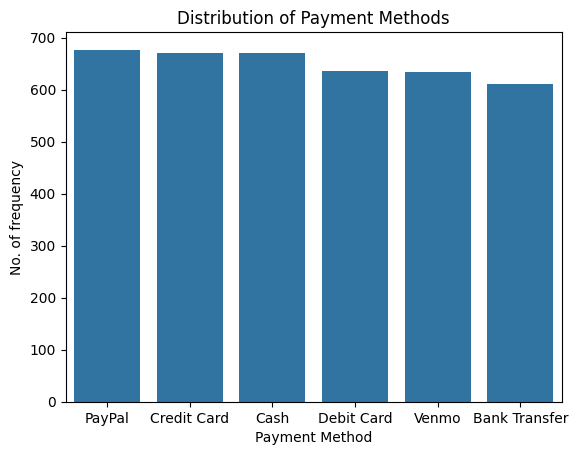

In [50]:
sns.countplot(x='Payment Method', order=df['Payment Method'].value_counts().index, data=df)

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("No. of frequency")

plt.savefig("graph001.png")
plt.show()

## The correct interpretation:

What: PayPal is most used (677), Bank Transfer is least used (612), with only 65 difference across all 6 methods
So what: Customers have no strong preference for any single payment method — all are used almost equally. This suggests the company has successfully diversified its payment options
Now what:

No urgent action needed on payment infrastructure
Since Bank Transfer is least used, consider whether it's worth maintaining or simplifying
Could investigate why Bank Transfer is least popular — possibly due to friction or slowness compared to digital options like PayPal or Venmo

<strong>Q10 — Which customers shop the least and how can we re-engage them? — </strong> Frequency Score , Customer ID

In [51]:
df.groupby('Frequency of Purchases')['Customer ID'].count().sort_values(ascending=False)

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: Customer ID, dtype: int64

In [52]:
annual_customers = df[df['Frequency of Purchases'] == 'Annually']

print(annual_customers['Age Group'].value_counts())
print(annual_customers['Gender'].value_counts())
print(annual_customers['Category'].value_counts())
print(annual_customers['Payment Method'].value_counts())

Age Group
56-70    187
36-45    115
18-25     94
46-55     89
26-35     87
Name: count, dtype: int64
Gender
Male      387
Female    185
Name: count, dtype: int64
Category
Clothing       258
Accessories    184
Footwear        87
Outerwear       43
Name: count, dtype: int64
Payment Method
PayPal           103
Venmo            103
Debit Card       101
Credit Card      100
Bank Transfer     83
Cash              82
Name: count, dtype: int64


## Complete Customer Persona:
"The typical disengaged annual shopper is an older male (56-70), who primarily purchases Clothing and prefers digital payment methods like PayPal or Venmo."

Re-engagement Strategy (Now What):
For 56-70 Male segment:

Send personalized email campaigns featuring Clothing deals
Offer loyalty rewards for increasing purchase frequency
Highlight easy digital payment options they already prefer (PayPal/Venmo)

For reactivation specifically:

Identify customers who haven't purchased in 6+ months
Send targeted "We miss you" discount offers
Create a subscription program — since they already use digital payments, auto-renewal would reduce friction

In [53]:
df.to_csv('cleaned_customer_data.csv', index=False)

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Customer ID             3900 non-null   int64   
 1   Age                     3900 non-null   int64   
 2   Gender                  3900 non-null   str     
 3   Item Purchased          3900 non-null   str     
 4   Category                3900 non-null   str     
 5   Purchase Amount (USD)   3900 non-null   int64   
 6   Location                3900 non-null   str     
 7   Size                    3900 non-null   str     
 8   Color                   3900 non-null   str     
 9   Season                  3900 non-null   str     
 10  Review Rating           3900 non-null   float64 
 11  Subscription Status     3900 non-null   str     
 12  Shipping Type           3900 non-null   str     
 13  Discount Applied        3900 non-null   str     
 14  Promo Code Used         3900 non-nu